<div style="border:1px solid #d8e2ef; border-radius:18px; padding:26px 30px; background:#ffffff;">
  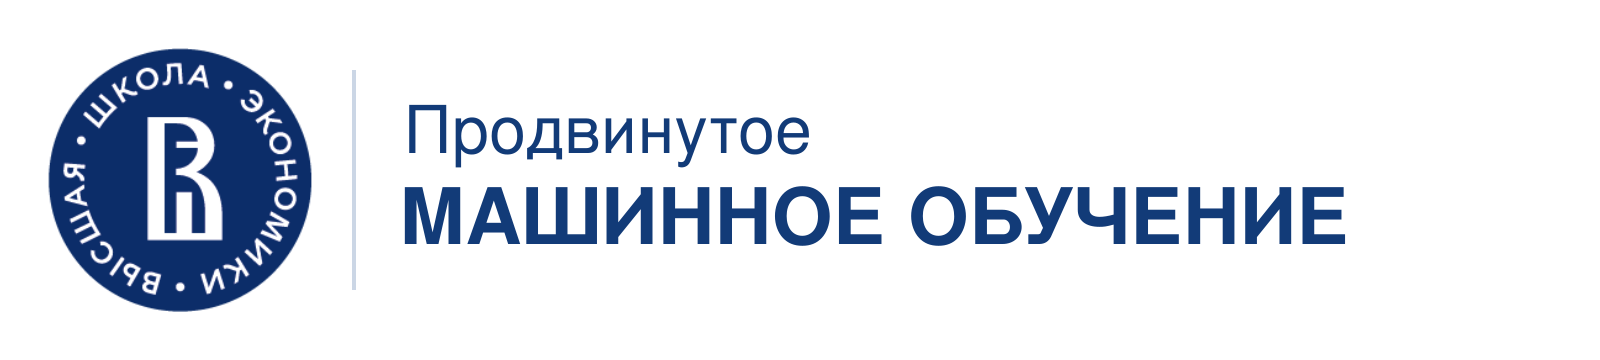

# Практика к лекции №1
## Надёжность ML-экспериментов
</div>


In [1]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42 # не меняйте, чтобы все ассерты корректно проходили

# здесь создаем независимые (i.i.d. как на лекции) наблюдения для заданий 2–3: числовой таргет и 30 признаков.
X, y = make_regression(
    n_samples=360, n_features=30, n_informative=8,
    noise=35, random_state=SEED, # шум везде из норм распределения
)
# разные масштабы признаков
X = X * np.logspace(-2, 2, X.shape[1])

print(f'X: {X.shape}, y: {y.shape}')

X: (360, 30), y: (360,)


### 1. Подсчет риска и generalization gap

Даны истинные значения и уже полученные предсказания одной фиксированной модели.
Тест не участвовал в её обучении или выборе.
Для квадратичной потери обозначения те же, что на лекции:

$$\widehat R_A(f)=\frac{1}{|A|}\sum_{i\in A}(f(x_i)-y_i)^2,
\qquad \widehat{\mathrm{gap}}=\widehat R_{\mathrm{test}}(f)-\widehat R_{\mathrm{train}}(f).$$

Допишите функцию `mse` средствами NumPy, затем вычислите оба риска и gap.
Данные этого задания используются только здесь (для остальных тасок будем использовать сгенерированные выше данные).


In [ ]:
y_train = np.array([1., 2., 3., 4.])
pred_train = np.array([1.2, 1.8, 3.1, 3.9])
y_test = np.array([1., 2., 3., 4.])
pred_test = np.array([1.5, 1.5, 2.5, 4.5])

def mse(y_true, y_pred):
    return None  # TODO: средняя квадратичная ошибка

train_risk = None  # TODO
test_risk = None   # TODO
gap = None         # TODO

In [ ]:
assert None not in (train_risk, test_risk, gap), 'Заполните TODO в задании 1.'
assert np.isclose(mse(np.array([0., 2.]), np.array([1., 0.])), 2.5)
assert np.isclose(train_risk, mean_squared_error(y_train, pred_train))
assert np.isclose(test_risk, mean_squared_error(y_test, pred_test))
assert np.isclose(gap, test_risk - train_risk), 'Проверьте порядок вычитания.'
print(f'train MSE = {train_risk:.3f}; test MSE = {test_risk:.3f}; gap = {gap:.3f}')

**Вопрос.** Достаточно ли положительного gap на четырёх тестовых объектах, чтобы уверенно объявить модель переобученной?

**Ваш ответ:** …


### 2. K-fold без утечки
На лекции мы обсуждали с вами кросс-валидацию, проклятие победителя, а также выбор той конфигурации гиперпараметров, которой "повезло" с шумом. Попробуем попрактиковаться с кросс-валидацией - пока что обычной.

Используем `X, y` из подготовленных выше данных. Соберите `Pipeline` из `StandardScaler` и `Ridge(alpha=1.0)`.
Назовите шаги `scale` и `model`. Затем допишите ручной цикл по пяти фолдам:
создавайте свежую копию pipeline, обучайте её на train-части и считайте MSE на validation-части.

Масштабирование должно обучаться **заново внутри каждого фолда**.
В этом задании `alpha` фиксирован; подбора гиперпараметров ещё нет.

<details>
<summary>Подсказка</summary>

`Pipeline` принимает список пар «имя шага, объект». `clone` создаёт необученную копию.
Для выбора строк NumPy-массива используйте `X[train_idx]`.

</details>


In [ ]:
pipeline = None  # TODO: StandardScaler → Ridge(alpha=1.0)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows, fitted_models = [], []

for fold, (train_idx, val_idx) in enumerate(cv.split(X), start=1):
    model = None  # TODO: необученная копия pipeline
    # TODO: обучите model только на train_idx
    pred = None   # TODO: предсказания для val_idx
    fold_mse = None  # TODO: MSE на val_idx
    cv_rows.append({'fold': fold, 'val_mse': fold_mse})
    fitted_models.append(model)

cv_results = pd.DataFrame(cv_rows)

In [ ]:
assert isinstance(pipeline, Pipeline), 'Соберите пайплайн.'
assert len(fitted_models) == 5 and len({id(m) for m in fitted_models}) == 5
assert np.isfinite(cv_results['val_mse'].to_numpy(dtype=float)).all()
for i, ((tr, va), model) in enumerate(zip(cv.split(X), fitted_models)):
    assert np.isclose(model.named_steps['model'].alpha, 1.0)
    scaler = model.named_steps['scale']
    assert scaler.n_samples_seen_ == len(tr), 'Scaler должен видеть только train-фолд.'
    np.testing.assert_allclose(scaler.mean_, X[tr].mean(axis=0))
    assert np.isclose(cv_results.iloc[i]['val_mse'],
                      mean_squared_error(y[va], model.predict(X[va])))
display(cv_results.round(2))
print(f"Средний CV MSE: {cv_results['val_mse'].mean():.2f}")

**Вопрос.** Что нарушится, если перед циклом вызвать `StandardScaler().fit_transform(X)`
на всей выборке? Считается ли это утечкой, если scaler не использует `y`?

**Ваш ответ:** …


### 3. Реализация nested cross-validation
А теперь попробуем реализовать более честную разновидность кросс-валидации (одну из тех, что мы обсудили с вами в ходе лекции - Nested cross-validation).

Подбираем силу регуляризации $\lambda$; в `Ridge` соответствующий параметр называется `alpha`.
Сетка и MSE заданы заранее. Оценим **процедуру подбора и обучения модели** с помощью 4 внешних
и 3 внутренних фолдов.

В каждом внешнем фолде:

1. Создайте новый `GridSearchCV` для pipeline из задания 2 с `cv=inner_cv`,
   `scoring="neg_mean_squared_error"`, `refit=True`.
2. Запустите поиск **только на `outer_train`**. Внутренний splitter получит именно эту подвыборку.
3. Предскажите `outer_test`, посчитайте внешний MSE и сохраните выбранный `alpha`.
   Внутренний MSE получите из `best_score_`, сменив знак.

`GridSearchCV` максимизирует score, поэтому для MSE используется отрицательное значение.
При `refit=True` выбранная модель автоматически обучается на всей выборке,
переданной в `fit`, то есть здесь — на `outer_train`.
Это поведение описано в [документации GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

<details>
<summary>Подсказка</summary>

Параметр шага pipeline задаётся через двойное подчёркивание: `model__alpha`.
После `search.fit(...)` доступны `search.predict(...)`, `search.best_score_` и `search.best_params_`.

</details>


Схема, чтобы было более интуитивно понятно, какая реализация от вас ожидается:

<img src="https://drive.google.com/thumbnail?id=1Injebftspdt911yBUfbQMoEEK9bSZxx4&sz=w1000" width="1000" />

In [ ]:
outer_cv = KFold(n_splits=4, shuffle=True, random_state=SEED)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=SEED + 1)
param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
nested_rows, fitted_searches = [], []

for fold, (outer_train, outer_test) in enumerate(outer_cv.split(X), start=1):
    search = None  # TODO: новый GridSearchCV для pipeline
    # TODO: запустите search.fit на внешней обучающей части
    outer_pred = None  # TODO: прогноз для outer_test
    inner_mse = None   # TODO: внутренний MSE выбранной конфигурации
    outer_mse = None   # TODO: внешний MSE
    best_alpha = None  # TODO: выбранный alpha
    nested_rows.append({
        'fold': fold, 'alpha': best_alpha,
        'inner_mse': inner_mse, 'outer_mse': outer_mse,
    })
    fitted_searches.append(search)

nested_results = pd.DataFrame(nested_rows)
nested_mse = None  # TODO: среднее внешних MSE

In [ ]:
assert len(fitted_searches) == 4 and len({id(s) for s in fitted_searches}) == 4
assert nested_mse is not None, 'Заполните TODO в задании 3.'
for i, ((tr, te), search) in enumerate(zip(outer_cv.split(X), fitted_searches)):
    assert isinstance(search, GridSearchCV) and search.n_splits_ == 3
    assert search.scoring == 'neg_mean_squared_error' and search.refit is True
    scaler = search.best_estimator_.named_steps['scale']
    assert scaler.n_samples_seen_ == len(tr), 'В поиск попал внешний тест.'
    np.testing.assert_allclose(scaler.mean_, X[tr].mean(axis=0))
    row = nested_results.iloc[i]
    assert np.isclose(row['alpha'], search.best_params_['model__alpha'])
    assert np.isclose(row['inner_mse'], -search.best_score_)
    assert np.isclose(row['outer_mse'], mean_squared_error(y[te], search.predict(X[te])))
assert np.isclose(nested_mse, nested_results['outer_mse'].mean())
display(nested_results.round(2))
print(f'Nested CV MSE: {nested_mse:.2f}')

**Вопрос.** Почему `-search.best_score_` не заменяет внешнюю оценку?
Обязательно ли внутренний MSE будет меньше внешнего на каждом фолде?

**Ваш ответ:** …


### 4. PIT: корректный временной сплит

Для каждой даты $t$ прогнозируем суммарный спрос за **следующие 7 дней**:
таргет использует окно $(t, t+7]$. Данные идут ежедневно, без пропусков.
`label_end` — последняя дата, нужная для вычисления таргета строки.

Пусть первый день валидации — $c$. Модель обучаем **перед началом этого дня**,
поэтому допустимы только обучающие строки с `label_end < c`.
Условие строгое: итоговые данные дня $c$ ещё неизвестны.

Создайте `TimeSeriesSplit` с тремя фолдами, `test_size=21` и **минимальным целым `gap`**,
который обеспечивает это условие. Сохраните пары индексов в `time_splits`.
В этом задании модель обучать не нужно: проверяем сам сплит.

<details>
<summary>Подсказка</summary>

Если validation начинается с индекса `j`, последний индекс train равен `j - gap - 1`.
Учтите, когда закончится окно таргета этой строки.
В `TimeSeriesSplit` параметр `gap` измеряется в **строках**, а не в днях.

</details>


In [ ]:
HORIZON = 7
time_data = pd.DataFrame({'t': pd.date_range('2026-01-01', periods=140, freq='D')})
time_data['label_end'] = time_data['t'] + pd.Timedelta(days=HORIZON)

# архив содержит события до этой даты включительно.
# последние строки без полностью наблюдённого таргета исключаем.
archive_end = time_data['t'].max()
time_data = time_data.loc[time_data['label_end'] <= archive_end].reset_index(drop=True)
display(time_data.iloc[[0, -1]])

In [ ]:
gap_days = None  # TODO: минимальный gap; здесь одна строка = один день
time_cv = None   # TODO: TimeSeriesSplit
time_splits = None  # TODO: список пар (train_idx, val_idx)

In [ ]:
assert time_splits is not None and len(time_splits) == 3
assert isinstance(time_cv, TimeSeriesSplit) and time_cv.gap == gap_days
assert isinstance(gap_days, (int, np.integer)) and gap_days > 0
time_rows = []
for tr, va in time_splits:
    train, val = time_data.iloc[tr], time_data.iloc[va]
    assert len(tr) > 0 and len(va) == 21 and not set(tr) & set(va)
    assert train['t'].max() < val['t'].min(), 'В обучении есть будущие строки.'
    assert train['label_end'].max() < val['t'].min(), 'Таргеты train ещё неизвестны!'
    assert va[0] - tr[-1] - 1 == gap_days
    time_rows.append({
        'train_end': train['t'].max().date(),
        'last_label_end': train['label_end'].max().date(),
        'val_start': val['t'].min().date(), 'val_end': val['t'].max().date(),
    })
shorter_cv = TimeSeriesSplit(n_splits=3, test_size=21, gap=gap_days - 1)
assert any(time_data.iloc[tr]['label_end'].max() >= time_data.iloc[va]['t'].min()
           for tr, va in shorter_cv.split(time_data)), 'Ваш gap безопасен, но не минимален. Надо поправить.'
display(pd.DataFrame(time_rows))
print('Порядок дат, доступность таргетов и минимальность gap проверены. Все отлично - вы молодец!')

**Вопрос.** Почему `gap=0` здесь приводит к утечке даже без перемешивания?
Можно ли использовать тот же `gap`, если наблюдения приходят в нерегулярные моменты?

**Ваш ответ:** …
